In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from skimage.filters import gabor
from skimage.color import rgb2gray
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [3]:
# Carrega as imagens e extrai as características com Gabor
def extrair_gabor(imagem_path, frequencias=[0.1, 0.3, 0.5], thetas=[0, np.pi/4, np.pi/2]):
    img = cv2.imread(imagem_path)
    img = cv2.resize(img, (224, 224))
    img_gray = rgb2gray(img)

    features = []
    for freq in frequencias:
        for theta in thetas:
            filt_real, _ = gabor(img_gray, frequency=freq, theta=theta)
            features.append(filt_real.mean())
            features.append(filt_real.var())

    return np.array(features)

def carregar_dataset(pasta):
    X, y, classes = [], [], []
    classes_nomes = sorted(os.listdir(pasta))

    for idx, classe in enumerate(classes_nomes):
        caminho_classe = os.path.join(pasta, classe)
        if not os.path.isdir(caminho_classe):
            continue
        for img_nome in os.listdir(caminho_classe):
            img_path = os.path.join(caminho_classe, img_nome)
            try:
                features = extrair_gabor(img_path)
                X.append(features)
                y.append(idx)
            except:
                pass

    print(f"Classes: {classes_nomes}")
    return np.array(X), np.array(y), classes_nomes

print("Carregando treino...")
X_treino, y_treino, CLASSES = carregar_dataset("/content/dataset/train")
print("Carregando teste...")
X_teste, y_teste, _ = carregar_dataset("/content/dataset/test")
print(f"Treino: {X_treino.shape} | Teste: {X_teste.shape}")

Carregando treino...
Classes: ['Dark', 'Green', 'Light', 'Medium']
Carregando teste...
Classes: ['Dark', 'Green', 'Light', 'Medium']
Treino: (1200, 18) | Teste: (400, 18)


In [4]:
# Normalizar e treinar
scaler = StandardScaler()
X_treino = scaler.fit_transform(X_treino)
X_teste = scaler.transform(X_teste)

modelo = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
print("Treinando SVM...")
modelo.fit(X_treino, y_treino)
print("Treinado")

Treinando SVM...
Treinado


In [5]:
# Métricas
y_pred = modelo.predict(X_teste)

acc = accuracy_score(y_teste, y_pred)
print(f"\nAcurácia: {acc:.4f} ({acc*100:.2f}%)\n")
print(classification_report(y_teste, y_pred, target_names=CLASSES))


Acurácia: 0.8675 (86.75%)

              precision    recall  f1-score   support

        Dark       0.86      0.87      0.87       100
       Green       0.91      0.90      0.90       100
       Light       0.84      0.87      0.85       100
      Medium       0.86      0.83      0.85       100

    accuracy                           0.87       400
   macro avg       0.87      0.87      0.87       400
weighted avg       0.87      0.87      0.87       400



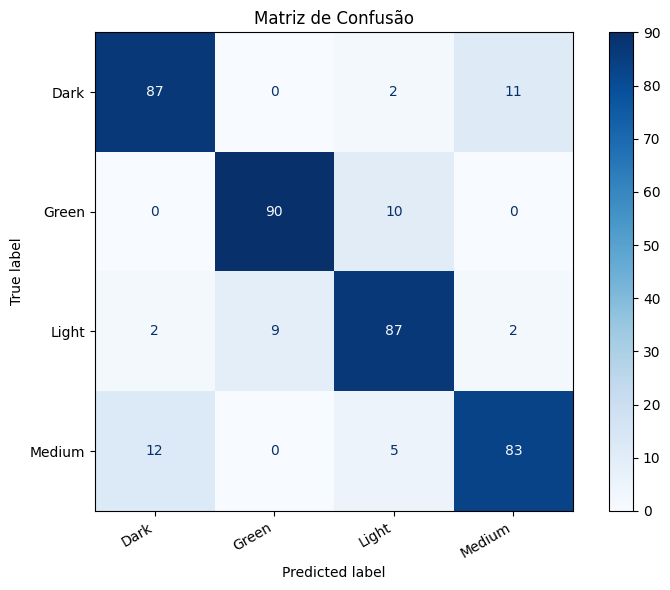

In [6]:
#  Matriz de confusão
cm = confusion_matrix(y_teste, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Matriz de Confusão')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()